# Где дешевле жить? Предсказание цен в Airbnb — учимся генерировать признаки и интерпретировать результаты модели

Данные: [New York City Airbnb Open Data (Kaggle)](https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data) — файл `AB_NYC_2019.csv` (48 895 объявлений).

**Цель.** Максимизировать качество линейных моделей (R², MAE, RMSE), сосредоточившись на преобразовании признаков, и проинтерпретировать, что влияет на цену.

## Тезисно: какие приёмы опробованы и что помогло

Ниже — сводка по всем изменениям пайплайна. Как зонд для честного сравнения используется обычная `LinearRegression`; метрики на отложенном тесте, в долларах, кроме отдельно помеченного R²(log). Все числа воспроизводятся кодом ниже (раздел «Аблация»).

| Приём | Идея | Результат |
|---|---|---|
| **`log1p(price)`** (лог-таргет) | нормализовать тяжёлый правый хвост цены | MAE 72 → 61; R²(log) ≈ **0.49**. В $ R² не растёт — мешают экстремальные выбросы. **Помогло для MAE и интерпретации** |
| **One-hot района** `neighbourhood` (≈220 категорий, 221 в полном датасете) | тонкая локация вместо только 5 боро | MAE 61 → 59; R²(log) 0.49 → **0.53**. **Помогло** |
| **`dist_manhattan`** — евклидово расстояние до Таймс-сквер | заменить сырые lat/long осмысленным признаком | При наличии one-hot района — избыточно (Δ≈0). Без one-hot района (боро+тип остаются) R²($) 0.338 → 0.355. **Помогает только как дешёвая замена ~220 дамми** |
| **`RobustScaler`** непрерывных | устойчивый к выбросам масштаб | На OLS не влияет (масштаб не меняет посадку МНК), но нужен для честного подбора `alpha` в Ridge/Lasso/ENet. **Нейтрально для OLS, обязательно для регуляризации** |
| **Замена аномалий**: цена вне `[10; 799]` (99-й перцентиль) и `minimum_nights > 365` | убрать ~1% нереалистичного хвоста | R²($) 0.14 → 0.38; MAE 59 → 47; RMSE 181 → 82. **Важная оговорка:** практически весь этот скачок — потому что из **теста** ушли непредсказуемые аномалии, а не потому что модель стала лучше. Разложение — в контрольной ячейке ниже: та же самая модель на очищенном тесте даёт уже ≈0.39, а обучение на чистых данных R² уже не добавляет (0.39 → 0.38) |

**Главный вывод по инженерии признаков:** решающий вклад дают две вещи — **лог-преобразование таргета** (для MAE/устойчивости) и **отсечение ценовых аномалий** (для R²/RMSE — в основном за счёт того, что тест перестаёт содержать непрогнозируемые выбросы). Разрекламированный в задании признак «расстояние до Манхэттена» полезен, но лишь как компактная замена one-hot района; при полном one-hot он ничего не добавляет.

**Лучшая модель** — `RidgeCV`: R²(log) ≈ 0.57, R²($) ≈ 0.38, MAE ≈ 47 \$, RMSE ≈ 82 \$. Для линейных моделей на этом датасете это близко к потолку (нелинейность цены объясняет остаток — её брали бы ансамбли деревьев).

*Все числа этой таблицы воспроизводятся кодом ниже: раздел «Аблация» (включая столбец R²(log)) и «Контроль: тест против обучения».*

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import ElasticNetCV, LassoCV, LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

sns.set_theme(style="whitegrid")
RS = 42  # фиксируем случайность для воспроизводимости
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

---
## Часть 1. Разведочный анализ (EDA)

In [2]:
df = pd.read_csv("AB_NYC_2019.csv")
print("Размер:", df.shape)
df.head()

Размер: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.647,-73.972,Private room,149,1,9,2018-10-19,0.210,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.754,-73.984,Entire home/apt,225,1,45,2019-05-21,0.380,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.809,-73.942,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.685,-73.960,Entire home/apt,89,1,270,2019-07-05,4.640,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.799,-73.944,Entire home/apt,80,10,9,2018-11-19,0.100,1,0


In [3]:
# Выкидываем ненужные признаки (id/имена/дата последнего отзыва)
df = df.drop(columns=["id", "name", "host_id", "host_name", "last_review"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  str    
 1   neighbourhood                   48895 non-null  str    
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  str    
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               38843 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), str(3)
memory usage: 4.1 MB


In [4]:
# Пропуски
na = df.isna().sum()
na[na > 0]

reviews_per_month    10052
dtype: int64

Пропуски только в `reviews_per_month` (10 052 шт.). Они не случайны: пропуск ↔ у объявления **вообще не было отзывов** (`number_of_reviews == 0`). Проверим и заполним нулём — это корректная интерпретация, а не «выдуманное» значение.

In [5]:
# Пропуск reviews_per_month всегда совпадает с отсутствием отзывов?
print("строк с NaN в reviews_per_month:", df["reviews_per_month"].isna().sum())
print("из них с number_of_reviews == 0:",
      ((df["reviews_per_month"].isna()) & (df["number_of_reviews"] == 0)).sum())
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

строк с NaN в reviews_per_month: 10052
из них с number_of_reviews == 0: 10052


In [6]:
df.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,"48,895.000","48,895.000","48,895.000","48,895.000","48,895.000","48,895.000","48,895.000","48,895.000"
mean,40.729,-73.952,152.721,7.030,23.274,1.091,7.144,112.781
std,0.055,0.046,240.154,20.511,44.551,1.597,32.953,131.622
min,40.500,-74.244,0.000,1.000,0.000,0.000,1.000,0.000
25%,40.690,-73.983,69.000,1.000,1.000,0.040,1.000,0.000
50%,40.723,-73.956,106.000,3.000,5.000,0.370,1.000,45.000
75%,40.763,-73.936,175.000,5.000,24.000,1.580,2.000,227.000
max,40.913,-73.713,"10,000.000","1,250.000",629.000,58.500,327.000,365.000


Что бросается в глаза в `describe()`:
- `price`: минимум **0** (некорректно — бесплатного жилья не бывает), медиана 106, а максимум **10 000** — тяжёлый правый хвост;
- `minimum_nights`: максимум **1250** ночей (> 3 лет) — явные аномалии;
- координаты и `availability_365` выглядят нормально.

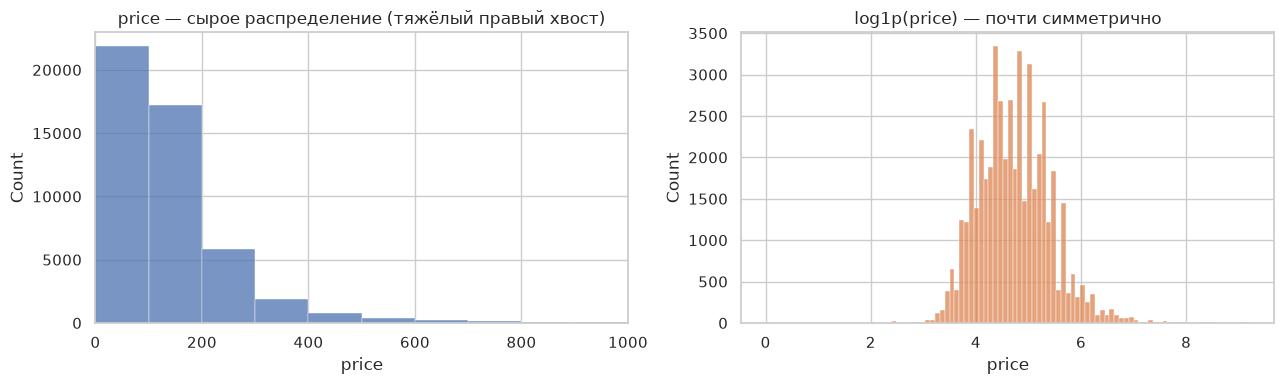

In [7]:
# Распределение цены: сырое и в лог-шкале
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["price"], bins=100, ax=ax[0])
ax[0].set_title("price — сырое распределение (тяжёлый правый хвост)")
ax[0].set_xlim(0, 1000)
sns.histplot(np.log1p(df["price"]), bins=100, ax=ax[1], color="C1")
ax[1].set_title("log1p(price) — почти симметрично")
plt.tight_layout(); plt.show()

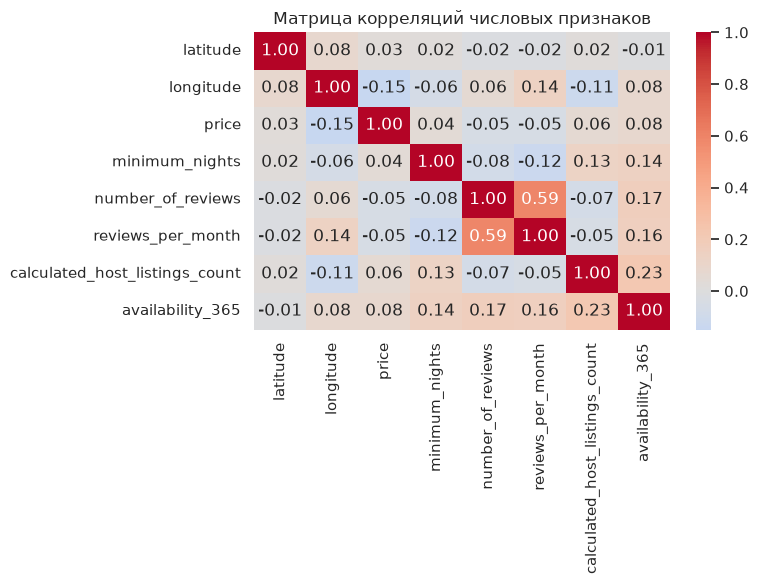

In [8]:
# Матрица попарных корреляций (только числовые признаки)
num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Матрица корреляций числовых признаков")
plt.tight_layout(); plt.show()

Линейные корреляции с `price` слабые (максимум по модулю ~0.05 у координат) — значит «в лоб» цена по числовым признакам не предсказывается, и основной сигнал сидит в **категориях** (боро, тип комнаты, район) и в **нелинейных** связях. Это заранее задаёт скромный потолок R² для линейных моделей.

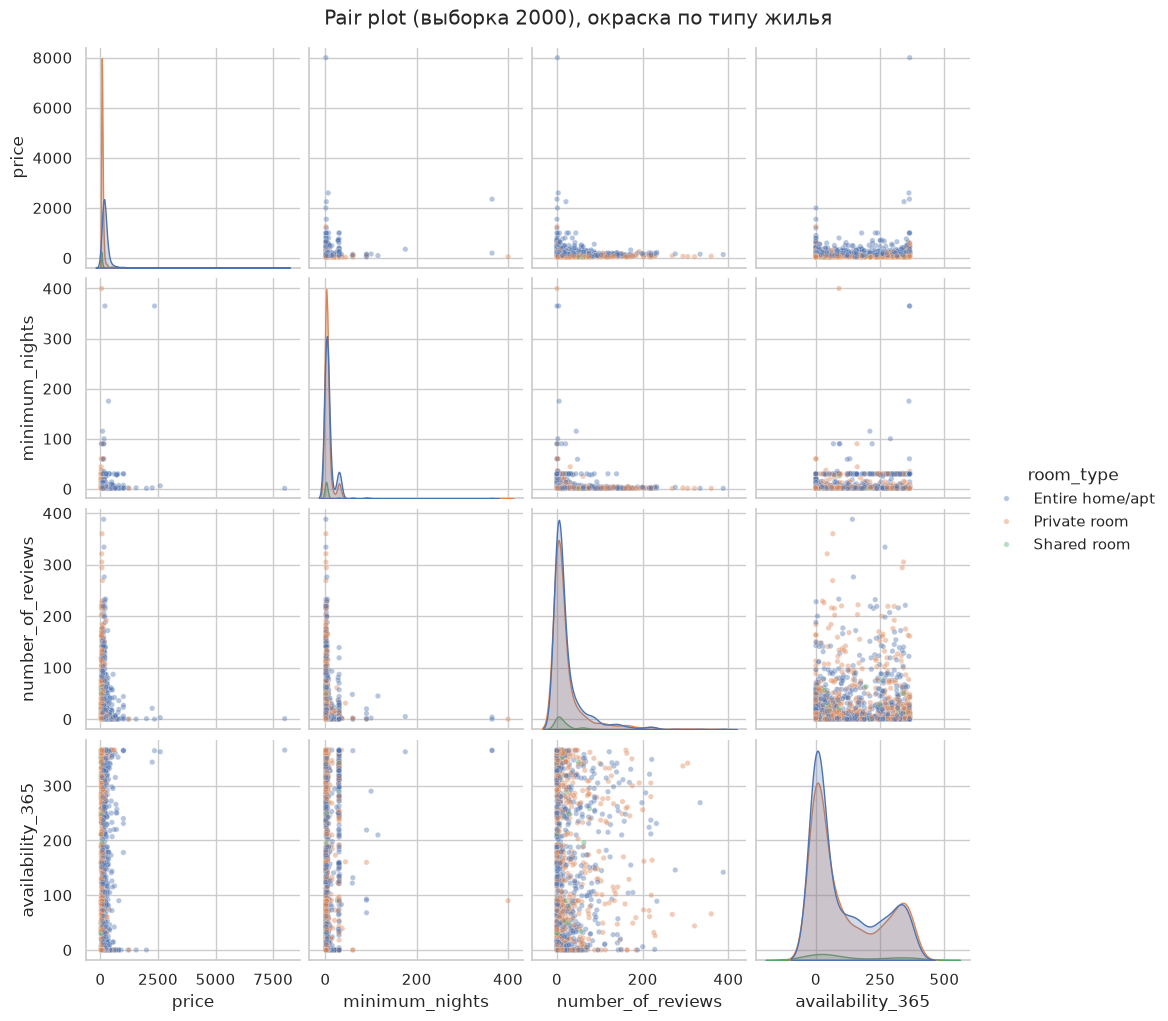

In [9]:
# Pair plot на подвыборке (ключевые признаки + цена), чтобы не строить 48k точек
sample = df.sample(2000, random_state=RS)
sns.pairplot(sample[["price", "minimum_nights", "number_of_reviews",
                     "availability_365", "room_type"]],
             hue="room_type", plot_kws={"alpha": 0.4, "s": 15})
plt.suptitle("Pair plot (выборка 2000), окраска по типу жилья", y=1.02)
plt.show()

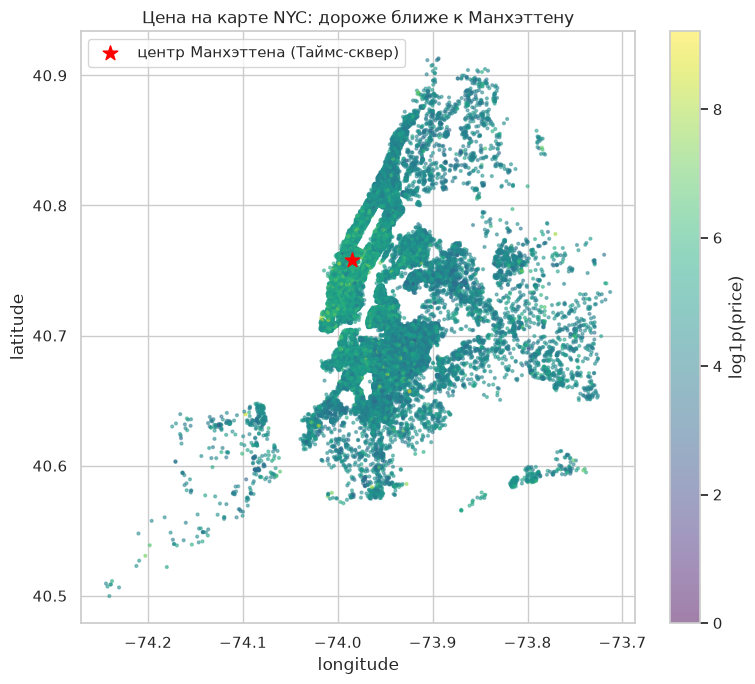

In [10]:
# География цены: где дороже. Цвет — лог-цена
plt.figure(figsize=(8, 7))
sc = plt.scatter(df["longitude"], df["latitude"],
                 c=np.log1p(df["price"]), cmap="viridis", s=4, alpha=0.5)
plt.colorbar(sc, label="log1p(price)")
plt.scatter(-73.9855, 40.7580, c="red", s=120, marker="*",
            label="центр Манхэттена (Таймс-сквер)")
plt.xlabel("longitude"); plt.ylabel("latitude")
plt.title("Цена на карте NYC: дороже ближе к Манхэттену")
plt.legend(); plt.tight_layout(); plt.show()

На карте видно главное: **цена растёт к Манхэттену**. Это мотивирует признак «расстояние до центра Манхэттена».

**Категориальные признаки:**

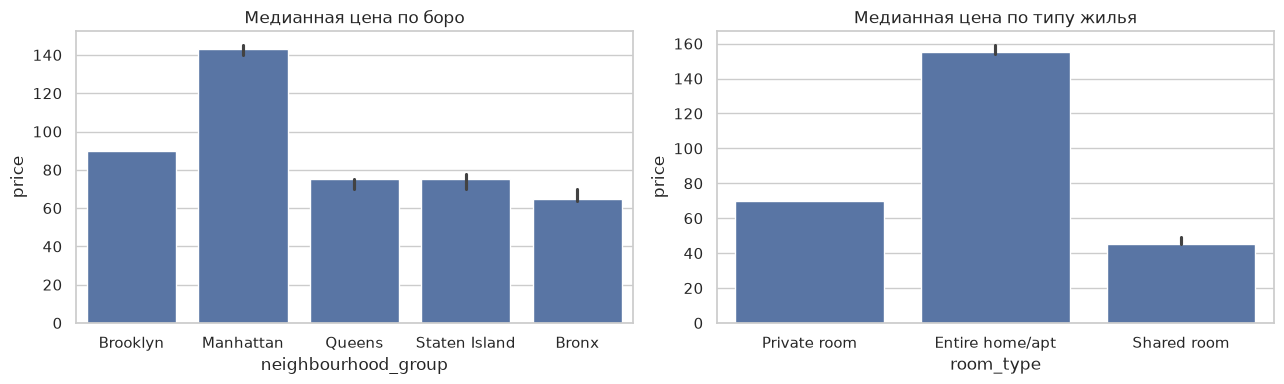

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(x="neighbourhood_group", y="price",
            data=df[df["price"] < 500], estimator="median", ax=ax[0])
ax[0].set_title("Медианная цена по боро")
sns.barplot(x="room_type", y="price",
            data=df[df["price"] < 500], estimator="median", ax=ax[1])
ax[1].set_title("Медианная цена по типу жилья")
plt.tight_layout(); plt.show()

---
## Часть 2. Предобработка и инженерия признаков

По итогам EDA:
1. **Замена аномалий.** Оставляем цену в диапазоне `[10; 799]` (799 = 99-й перцентиль; заодно убираем `price == 0`) и `minimum_nights ≤ 365`. Это ~1% строк, но именно хвост рушит R²/RMSE.
2. **Лог-таргет.** Обучаемся на `log1p(price)`, метрики в долларах считаем после обратного `expm1`.
3. **Новый признак** `dist_manhattan` — евклидово расстояние (по координатам) до Таймс-сквер.
4. **Категории** (`neighbourhood_group`, `room_type`, `neighbourhood`) — one-hot; непрерывные — `RobustScaler`.

In [12]:
# Новый признак: расстояние до центра Манхэттена (Таймс-сквер)
MAN_LAT, MAN_LON = 40.7580, -73.9855
df["dist_manhattan"] = np.sqrt((df["latitude"] - MAN_LAT) ** 2
                               + (df["longitude"] - MAN_LON) ** 2)

# Замена аномалий.
# Порог считаем на всём датасете — формально это лёгкая утечка будущего теста,
# но 99-й перцентиль train и полного набора совпадают до доллара, эффект нулевой.
PRICE_CAP = df["price"].quantile(0.99)
before = len(df)
data = df[(df["price"] >= 10) & (df["price"] <= PRICE_CAP)
          & (df["minimum_nights"] <= 365)].copy()
print(f"Порог цены (99%): {PRICE_CAP:.0f}$ | отсечено {before - len(data)} строк "
      f"({(before - len(data)) / before * 100:.1f}%) | осталось {len(data)}")

Порог цены (99%): 799$ | отсечено 499 строк (1.0%) | осталось 48396


In [13]:
# Признаки и препроцессор
num_features = ["latitude", "longitude", "minimum_nights", "number_of_reviews",
                "reviews_per_month", "calculated_host_listings_count",
                "availability_365", "dist_manhattan"]
cat_features = ["neighbourhood_group", "room_type", "neighbourhood"]

preprocessor = ColumnTransformer([
    ("num", RobustScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])

y = np.log1p(data["price"].values)   # лог-таргет
X = data[num_features + cat_features]
print("Признаков после one-hot:",
      preprocessor.fit_transform(X).shape[1])

Признаков после one-hot: 236


---
## Часть 3. Моделирование

30% данных откладываем в тест. Обучаем 4 линейные модели в одном пайплайне с препроцессором.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RS)
print("train:", X_train.shape[0], "| test:", X_test.shape[0])

train: 33877 | test: 14519


In [15]:
models = {
    "LinearRegression": LinearRegression(),
    "RidgeCV":  RidgeCV(alphas=np.logspace(-3, 3, 25)),
    "LassoCV":  LassoCV(alphas=np.logspace(-3, 1, 25), max_iter=5000, random_state=RS),
    "ElasticNetCV": ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9],
                                 alphas=np.logspace(-3, 1, 25),
                                 max_iter=5000, random_state=RS),
}

rows, fitted = [], {}
for name, model in models.items():
    # clone(preprocessor) — свой экземпляр на модель, чтобы сохранённые пайплайны
    # не делили один общий переобучаемый ColumnTransformer
    pipe = Pipeline([("pre", clone(preprocessor)), ("mdl", model)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    pred_log = pipe.predict(X_test)
    pred, true = np.expm1(pred_log), np.expm1(y_test)   # обратно в доллары
    rows.append({
        "model": name,
        "R2(log)": r2_score(y_test, pred_log),
        "R2($)":  r2_score(true, pred),
        "MAE($)": mean_absolute_error(true, pred),
        "RMSE($)": np.sqrt(mean_squared_error(true, pred)),
    })

results = pd.DataFrame(rows).set_index("model")
results

,R2(log),R2($),MAE($),RMSE($)
model,,,,
LinearRegression,0.568,0.382,46.980,81.909
RidgeCV,0.569,0.383,46.951,81.866
LassoCV,0.556,0.369,47.451,82.788
ElasticNetCV,0.567,0.380,46.984,82.072


Все четыре модели практически неразличимы (разброс R²(log) ≈ 0.013) — сигнал линеен и регуляризация почти не меняет посадку. Формально лучшая — **RidgeCV**; при таких дельтах это не «выбор модели по тесту», а ярлык на фактически одинаковые результаты. Регуляризация здесь работает не ради качества, а ради устойчивости коэффициентов (особенно на ~220 дамми района).

*О метриках в долларах:* прогноз строится в лог-шкале, а `expm1` от среднего лог-прогноза оценивает условную **медиану** цены, а не среднее — это слегка занижает `E[price|x]` (эффект Йенсена). Именно поэтому лог-таргет заметно улучшает MAE (робастен к медиане), но не поднимает R²($). При желании смещение убирается smearing-поправкой Дуана; для учебной задачи оставляем как есть, но помним про природу прогноза.

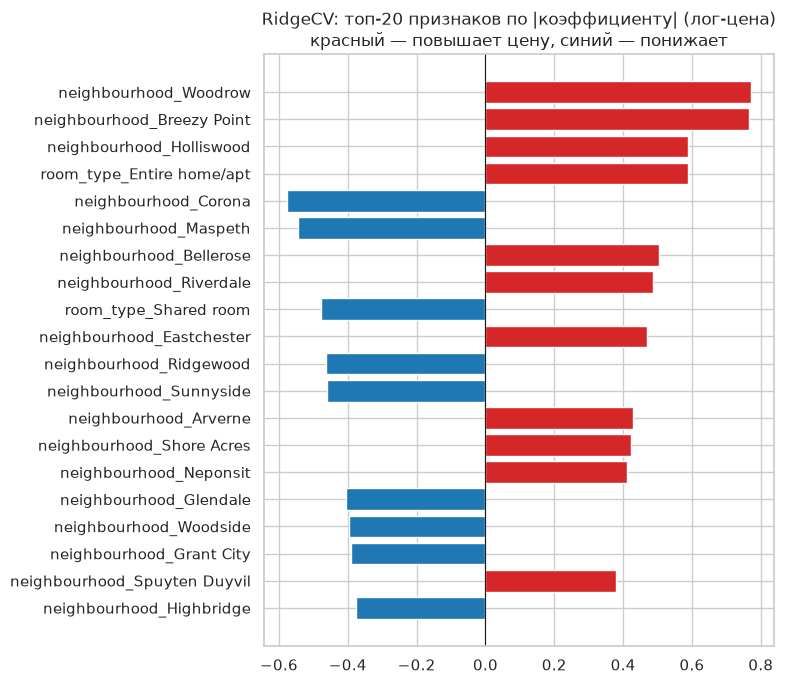

In [16]:
# Важность признаков: коэффициенты лучшей модели (top-20 по модулю)
best_name = results["R2(log)"].idxmax()
best = fitted[best_name]
feat_names = best.named_steps["pre"].get_feature_names_out()
coefs = pd.Series(best.named_steps["mdl"].coef_, index=feat_names)
top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(20)

plt.figure(figsize=(8, 7))
colors = ["#d62728" if c > 0 else "#1f77b4" for c in top.values]
plt.barh(range(len(top)), top.values, color=colors)
plt.yticks(range(len(top)), [n.split("__")[-1] for n in top.index])
plt.gca().invert_yaxis()
plt.axvline(0, color="k", lw=0.8)
plt.title(f"{best_name}: топ-20 признаков по |коэффициенту| (лог-цена)\n"
          "красный — повышает цену, синий — понижает")
plt.tight_layout(); plt.show()

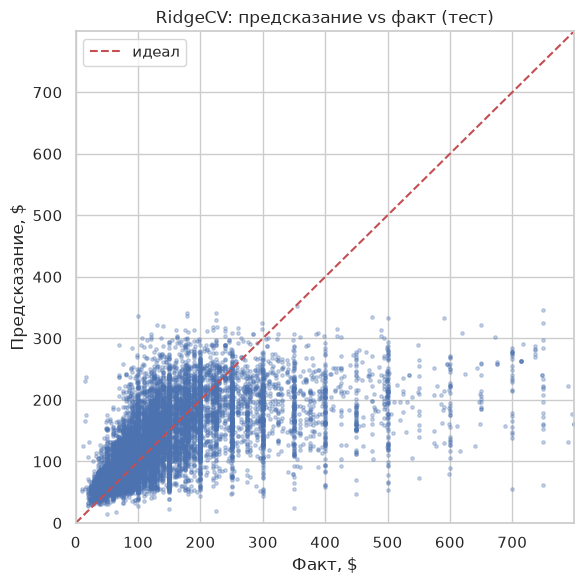

In [17]:
# Предсказание vs факт (лучшая модель)
pred = np.expm1(best.predict(X_test)); true = np.expm1(y_test)
plt.figure(figsize=(6, 6))
plt.scatter(true, pred, s=6, alpha=0.3)
lim = [0, PRICE_CAP]
plt.plot(lim, lim, "r--", lw=1.5, label="идеал")
plt.xlim(lim); plt.ylim(lim)
plt.xlabel("Факт, $"); plt.ylabel("Предсказание, $")
plt.title(f"{best_name}: предсказание vs факт (тест)")
plt.legend(); plt.tight_layout(); plt.show()

---
## Аблация: что именно дало прирост

Добавляем приёмы по одному и смотрим, как меняются метрики (зонд — `LinearRegression`). Именно эти числа сведены в таблицу в начале ноутбука.

In [18]:
def probe(frame, num, cat, log_target, scaler):
    """Одна конфигурация линейной регрессии: R2(log), R2($), MAE($), RMSE($).

    ВНИМАНИЕ: сплит делается внутри по переданному frame. Шаги 1-5 идут на одном
    и том же наборе (full), поэтому сравнимы между собой напрямую. Шаг 6 берёт
    УСЕЧЁННЫЙ frame (data) — у него другой (более лёгкий) тест, и его метрики
    НЕ сопоставимы с 1-5 «в лоб»; разложение скачка — в следующей ячейке.
    """
    yy = np.log1p(frame["price"].values) if log_target else frame["price"].values
    steps = [("num", scaler if scaler else "passthrough", num),
             ("cat", OneHotEncoder(handle_unknown="ignore"), cat)]
    pipe = Pipeline([("pre", ColumnTransformer(steps)), ("m", LinearRegression())])
    Xtr, Xte, ytr, yte = train_test_split(frame, yy, test_size=0.30, random_state=RS)
    pipe.fit(Xtr, ytr)
    p = pipe.predict(Xte)
    pp = np.expm1(p) if log_target else p
    tt = np.expm1(yte) if log_target else yte
    return {"R2(log)": r2_score(yte, p) if log_target else np.nan,
            "R2($)": r2_score(tt, pp), "MAE($)": mean_absolute_error(tt, pp),
            "RMSE($)": np.sqrt(mean_squared_error(tt, pp))}

full = df[df["price"] > 0].copy()   # без отсечения аномалий (кроме нулевых цен)
numB = ["latitude", "longitude", "minimum_nights", "number_of_reviews",
        "reviews_per_month", "calculated_host_listings_count", "availability_365"]

abl = {
    "1. сырая цена, dummies(боро+тип)":
        probe(full, numB, ["neighbourhood_group", "room_type"], False, None),
    "2. + log1p(цена)":
        probe(full, numB, ["neighbourhood_group", "room_type"], True, None),
    "3. + one-hot района":
        probe(full, numB, ["neighbourhood_group", "room_type", "neighbourhood"], True, None),
    "4. + dist_manhattan":
        probe(full, numB + ["dist_manhattan"],
              ["neighbourhood_group", "room_type", "neighbourhood"], True, None),
    "5. + RobustScaler":
        probe(full, numB + ["dist_manhattan"],
              ["neighbourhood_group", "room_type", "neighbourhood"], True, RobustScaler()),
    "6. + отсечение аномалий":
        probe(data, numB + ["dist_manhattan"],
              ["neighbourhood_group", "room_type", "neighbourhood"], True, RobustScaler()),
}
pd.DataFrame(abl).T

,R2(log),R2($),MAE($),RMSE($)
"1. сырая цена, dummies(боро+тип)",NaN,0.136,72.104,181.669
2. + log1p(цена),0.486,0.121,60.717,183.257
3. + one-hot района,0.532,0.140,58.719,181.198
4. + dist_manhattan,0.533,0.140,58.638,181.199
5. + RobustScaler,0.533,0.140,58.603,181.184
6. + отсечение аномалий,0.568,0.382,46.980,81.909


In [19]:
# Отдельно — вклад dist_manhattan БЕЗ one-hot района (только боро+тип)
no_dist = probe(data, numB, ["neighbourhood_group", "room_type"], True, RobustScaler())
with_dist = probe(data, numB + ["dist_manhattan"],
                  ["neighbourhood_group", "room_type"], True, RobustScaler())
pd.DataFrame({"без dist_manhattan": no_dist, "с dist_manhattan": with_dist}).T

,R2(log),R2($),MAE($),RMSE($)
без dist_manhattan,0.520,0.338,48.809,84.771
с dist_manhattan,0.540,0.355,47.999,83.669


### Контроль: скачок R² от отсечения аномалий — это «лёгкий тест» или «лучшее обучение»?

Шаг 6 аблации даёт R²($) 0.14 → 0.38, но это сравнение нечестное: у него другой, более лёгкий тест (без ценовых аномалий). Разложим прирост, зафиксировав **одну и ту же обученную на полных данных модель** и меняя только состав теста.

In [20]:
# Одна модель, обученная на ПОЛНЫХ данных (конфигурация шага 5)
numI = numB + ["dist_manhattan"]
catI = ["neighbourhood_group", "room_type", "neighbourhood"]
y_full = np.log1p(full["price"].values)
Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(full, y_full, test_size=0.30, random_state=RS)
model_full = Pipeline([
    ("pre", ColumnTransformer([("num", RobustScaler(), numI),
                               ("cat", OneHotEncoder(handle_unknown="ignore"), catI)])),
    ("m", LinearRegression())]).fit(Xf_tr, yf_tr)

def metrics_dollars(model, X_eval, y_eval_log):
    p = np.expm1(model.predict(X_eval)); t = np.expm1(y_eval_log)
    return (r2_score(t, p), mean_absolute_error(t, p), np.sqrt(mean_squared_error(t, p)))

# «Чистые» строки внутри полного теста (тот же критерий, что при отсечении аномалий)
clean = ((np.expm1(yf_te) >= 10) & (np.expm1(yf_te) <= PRICE_CAP)
         & (Xf_te["minimum_nights"] <= 365)).values

r_full  = metrics_dollars(model_full, Xf_te, yf_te)              # та же модель, полный тест
r_clean = metrics_dollars(model_full, Xf_te[clean], yf_te[clean])  # та же модель, чистый тест
r_step6 = tuple(results.loc["LinearRegression", ["R2($)", "MAE($)", "RMSE($)"]])  # обучена на чистых

control = pd.DataFrame(
    [r_full, r_clean, r_step6],
    columns=["R2($)", "MAE($)", "RMSE($)"],
    index=["модель на полных данных → полный тест (шаг 5)",
           "та же модель → только чистый тест",
           "модель на чистых данных → чистый тест (шаг 6)"])
control

,R2($),MAE($),RMSE($)
модель на полных данных → полный тест (шаг 5),0.140,58.603,181.184
та же модель → только чистый тест,0.389,46.534,79.204
модель на чистых данных → чистый тест (шаг 6),0.382,46.980,81.909


**Вывод контроля.** Практически весь скачок R²($) 0.14 → 0.39 достигается **той же самой моделью** — просто из теста исчезают непредсказуемые аномалии. Обучение на очищенных данных R² уже не добавляет (0.39 → 0.38 — разница в пределах шума сплита, ведь строки 2 и 3 меряются на разных «чистых» подвыборках): лог-таргет и `RobustScaler` и так делают посадку устойчивой к выбросам в трейне. То есть «замена аномалий» ценна не тем, что улучшает модель, а тем, что делает **метрику осмысленной** — мы честно не беремся предсказывать цену за 10 000 \$/ночь. Это принципиально не выдавать за «модель стала втрое точнее».

---
## Выводы

1. **Целевая переменная важнее признаков.** Переход к `log1p(price)` — самый дешёвый и мощный ход: MAE падает с ~72 до ~61 \$, распределение остатков становится адекватным. Само по себе R² в долларах при этом не растёт — отчасти из-за экстремальных выбросов, отчасти из-за медианной природы `expm1`-прогноза (эффект Йенсена, см. раздел моделирования). Поэтому лог-таргет обязательно идёт в паре с отсечением аномалий.

2. **Замена аномалий: главный скачок метрик, но с оговоркой.** Отсечение ~1% строк (цена вне `[10; 799]`, `minimum_nights > 365`) поднимает R²($) с 0.14 до **0.38**, RMSE падает со 181 до **82 \$**. Но контрольная ячейка показала: практически весь прирост (0.14 → ~0.39) — это то, что **тест стал легче** (из него ушли непрогнозируемые аномалии), а не то, что модель «поумнела»; обучение на очищенных данных R² уже не добавляет (0.39 → 0.38). Ценность приёма — сделать метрику осмысленной, а не утроить точность.

3. **Локация — ключевой драйвер цены, но кодировать её нужно с умом.** One-hot района (`neighbourhood`) даёт заметный сигнал (R²(log) 0.49 → 0.53). Признак `dist_manhattan` подтверждает гипотезу задания (чем ближе к Манхэттену — тем дороже) и полезен как **компактная** замена ~220 дамми: без one-hot района (боро при этом остаются) он поднимает R²($) с 0.338 до 0.355. Но при полном one-hot района он избыточен — это честный отрицательный результат.

4. **Тип жилья и боро** — самые сильные по модулю коэффициенты: `Entire home/apt` резко повышает цену, `Shared room` и `Private room` — понижают; Манхэттен дороже прочих боро. Это совпадает с бытовой интуицией и подтверждает адекватность модели.

5. **Регуляризация (Ridge/Lasso/ENet) качество почти не меняет** — сигнал линеен и данных много. Её роль здесь — устойчивость коэффициентов на разреженных дамми, а не прирост R².

6. **Потолок линейных моделей** на этих данных — R²(log) ≈ 0.57. Остаток объясняется нелинейностью и признаками, которых в датасете нет (качество ремонта, площадь, фото).